# Screening

Screening is enabled by default for different integral and evaluation calculations in `gbasis`. This helps reduce computation time and memory usage without sacrificing accuracy. This notebook demonstrates the screening feature of `gbasis` on a small molecule (formaldehyde). It includes two examples of screening: one-index screening, where only one contraction is involved in the evaluation, and two-index screening, where two Gaussian contractions are involved in the integration.

## one-index screening

When evaluating a property on a set of grid points, not all points yield non-negligible values for all basis functions. In fact, many points correspond to zero or negligible contributions from a given basis function. This can be estimated by introducing an energy tolerance $\epsilon$ and calculating a cutoff distance $d_{s,p}$ for each primitive $s$ and each grid point $p$. Then, when evaluating a basis function, the calculation is restricted to points that lie within the maximum cutoff distance over all primitives associated with that basis function. The screening is available for the following functions:

- [`evaluate_basis()`](http://gbasis.qcdevs.org/_autosummary/gbasis.evals.html?highlight=evaluate_density#gbasis.evals.eval.evaluate_basis)
- [`evaluate_deriv_basis()`](http://gbasis.qcdevs.org/_autosummary/gbasis.evals.html?highlight=evaluate_density#gbasis.evals.eval_deriv.evaluate_deriv_basis)
- [`evaluate_density()`](http://gbasis.qcdevs.org/_autosummary/gbasis.evals.html?highlight=evaluate_density#gbasis.evals.density.evaluate_density)
- [`evaluate_deriv_reduced_density_matrix()`](http://gbasis.qcdevs.org/_autosummary/gbasis.evals.html?highlight=evaluate_density#gbasis.evals.density.evaluate_deriv_reduced_density_matrix)
- [`evaluate_deriv_density()`](http://gbasis.qcdevs.org/_autosummary/gbasis.evals.html?highlight=evaluate_density#gbasis.evals.density.evaluate_deriv_density)
- [`evaluate_density_gradient()`](http://gbasis.qcdevs.org/_autosummary/gbasis.evals.html?highlight=evaluate_density#gbasis.evals.density.evaluate_density_gradient)
- [`evaluate_density_laplacian()`](http://gbasis.qcdevs.org/_autosummary/gbasis.evals.html?highlight=evaluate_density#gbasis.evals.density.evaluate_density_laplacian)
- [`evaluate_density_hessian()`](http://gbasis.qcdevs.org/_autosummary/gbasis.evals.html?highlight=evaluate_density#gbasis.evals.density.evaluate_density_hessian)
- [`evaluate_posdef_kinetic_energy_density()`](http://gbasis.qcdevs.org/_autosummary/gbasis.evals.html?highlight=evaluate_density#gbasis.evals.density.evaluate_posdef_kinetic_energy_density)
- [`evaluate_general_kinetic_energy_density()`](http://gbasis.qcdevs.org/_autosummary/gbasis.evals.html?highlight=evaluate_density#gbasis.evals.density.evaluate_general_kinetic_energy_density)

### Loading data
To evaluate properties dependent on the system state, we need its wavefunction or an equivalent representation. In `gbasis`, this is done through the one-electron reduced density matrix (1-RDM). As a case example, the following code will load this data from a `.fchk` file corresponding to a UB3LYP/Aug-cc-pVTZ calculation on formaldehyde. We will be using the [`iodata`](https://iodata.readthedocs.io/en/latest/) package to load the data.

### Defining the grid
We also need to define an auxiliary set of grid points to evaluate the properties. The loaded system is planar and all of its atoms lie on the $xy$ plane ($z=0$) in this specific case. So for simplicity, we will perform all successive analysis on the $xy$ plane. We define a grid of points in the $xy$ plane spanning the area enclosed by: $-5 \leq x \leq 5$ and $-5 \leq y \leq 5$. This grid will be used to evaluate the properties of interest, in this case electron density

In [5]:
import numpy as np
from iodata import load_one
from gbasis.wrappers import from_iodata

## load molecule info and basis from fchk file
mol = load_one("ch2o_q_0.fchk")
basis = from_iodata(mol) 
rdm = mol.one_rdms["scf"]
atcoords = mol.atcoords
atnums = mol.atnums

## make grid
grid_1d = np.linspace(-5, 5, 50)
grid_x, grid_y = np.meshgrid(grid_1d, grid_1d)
grid_z = np.zeros_like(grid_x)
points = np.vstack([grid_x.ravel(), grid_y.ravel(), grid_z.ravel()]).T

### Electron density

The electron density is the most fundamental property that can be obtained from the 1-RDM, and it can be evaluated at an array of points using the [`evaluate_density()`](http://gbasis.qcdevs.org/_autosummary/gbasis.evals.html?highlight=evaluate_density#gbasis.evals.density.evaluate_density) function. In this section, we calculate the electron density as an example of a one-index evaluation and display it on the molecular plane. For this example, screening is disabled with `screen_basis = False`.

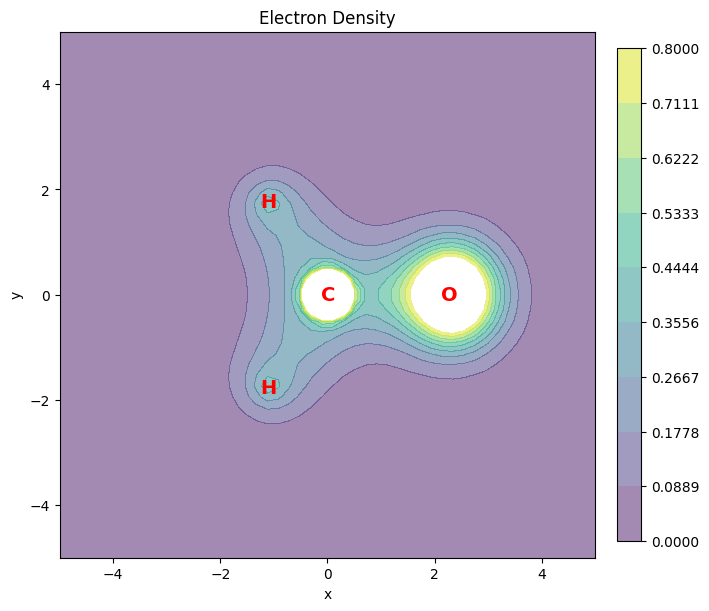

In [6]:
import matplotlib.pyplot as plt
from gbasis.evals.density import evaluate_density

## compute electron density without screening
rho_unscreened = evaluate_density(rdm, basis, points, screen_basis=False)

## plot electron density
X = points[:, 0].reshape(50, 50)
Y = points[:, 1].reshape(50, 50)
rho = rho_unscreened.reshape(50, 50)

fig1, ax1 = plt.subplots(figsize=(7, 6), constrained_layout=True)
rho_plot = ax1.contourf(X, Y, rho, levels=np.linspace(0, 0.8, 10), cmap="viridis", alpha=0.5)
ax1.set_title("Electron Density")
ax1.set_xlabel("x")
ax1.set_ylabel("y")

## add atomic symbols
symbols = ["O", "C", "H", "H"]
xy_coords = atcoords[:, :2]
for coord, symbol in zip(xy_coords, symbols):
    ax1.text(
        coord[0], coord[1], symbol,
        color="red", ha="center", va="center",
        fontsize=14, fontweight="bold"
    )

## colorbar
fig1.colorbar(rho_plot, ax=ax1, orientation="vertical", fraction=0.046, pad=0.04)
plt.show()

Now we calculate the electron density for the same system, but with screening enabled (the default) and using the default tolerance value ($10^{-8}$). The screening tolerance can be modified by setting `tol_screen = X` inside the `evaluate_density()` function. We then compare the screened and unscreened electron densities, calculate their difference, and plot it.

Are the screened and unscreened electron densities identical within 1e-4: True

Maximum difference between screened and unscreened electron densities: 2e-09



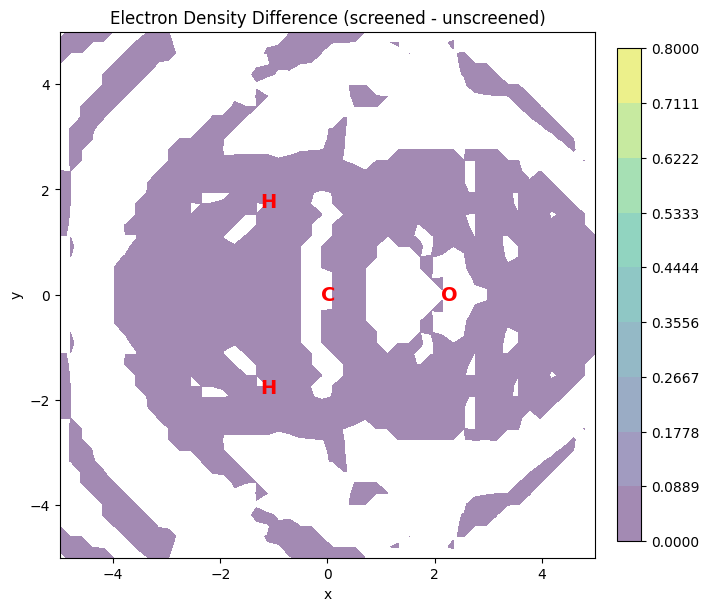

In [7]:
## compute electron density with screening
rho_screened = evaluate_density(rdm, basis, points) ## screen_basis=True, tol_screen=1e-8: defaults
print(f"Are the screened and unscreened electron densities identical within 1e-4: {np.allclose(rho_unscreened, rho_screened, atol=1e-4)}\n")
print(f"Maximum difference between screened and unscreened electron densities: {np.max(np.abs(rho_unscreened - rho_screened)):.0e}\n")

## calculate the difference between screened and unscreened electron density for plotting
delta_rho = (rho_screened - rho_unscreened).reshape(50, 50)

## plot the difference in screened and unscreened electron densities
fig2, ax2 = plt.subplots(figsize=(7, 6), constrained_layout=True)
delta_rho_plot = ax2.contourf(X, Y, delta_rho, levels=np.linspace(0, 0.8, 10), cmap="viridis", alpha=0.5)
ax2.set_title("Electron Density Difference (screened - unscreened)")
ax2.set_xlabel("x")
ax2.set_ylabel("y")

## add atomic symbols
for coord, symbol in zip(xy_coords, symbols):
    ax2.text(
        coord[0], coord[1], symbol,
        color="red", ha="center", va="center",
        fontsize=14, fontweight="bold"
    )

## color bar
fig2.colorbar(delta_rho_plot, ax=ax2, orientation="vertical", fraction=0.046, pad=0.04)
plt.show()


We can see that the screened and unscreened electron densities are identical, with the maximum difference being negligible. The plot clearly shows that there is practically no difference in accuracy between the two electron densities.

## Two-index screening
When calculating one-electron integrals between two basis functions, the overlap is zero or negligible if the functions are far apart. We can estimate a cutoff distance $d_{s,t}$ for each pair of basis functions $s$ and $t$ using an energy tolerance $\epsilon$, and return zero instead of performing the integral when the distance between the basis functions exceeds this cutoff. The screening is available for the following integrals:

- [`angular_momentum_integral()`](http://gbasis.qcdevs.org/_autosummary/gbasis.integrals.html?highlight=evaluate_density#gbasis.integrals.angular_momentum.angular_momentum_integral)
- [`kinetic_energy_integral()`](http://gbasis.qcdevs.org/_autosummary/gbasis.integrals.html?highlight=evaluate_density#gbasis.integrals.kinetic_energy.kinetic_energy_integral)
- [`moment_integral()`](http://gbasis.qcdevs.org/_autosummary/gbasis.integrals.html?highlight=evaluate_density#gbasis.integrals.moment.moment_integral)
- [`momentum_integral()`](http://gbasis.qcdevs.org/_autosummary/gbasis.integrals.html?highlight=evaluate_density#gbasis.integrals.momentum.momentum_integral)
- [`overlap_integral()`](http://gbasis.qcdevs.org/_autosummary/gbasis.integrals.html?highlight=evaluate_density#gbasis.integrals.overlap.overlap_integral)
- [`overlap_integral_asymmetric()`](http://gbasis.qcdevs.org/_autosummary/gbasis.integrals.html?highlight=evaluate_density#gbasis.integrals.overlap_asymm.overlap_integral_asymmetric)

### Dipole moment
To illustrate two-index screening, we calculate the dipole moment integrals with and without screening. We then use the 1-RDM to compute the electronic dipole moment of the system. By comparing both the dipole moment integrals and the resulting electronic dipole moment of the molecule, we can assess the effect of screening on these quantities.

In [8]:
from gbasis.integrals.moment import moment_integral

## set the orders of the moment integrals
order = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])

## calculate center of mass
center_of_mass = mol.atcorenums @ mol.atcoords / np.sum(mol.atcorenums)

## compute dipole moment integrals of a set of molecular orbitals without screening
electric_moment_integral_unscreened = moment_integral(basis, center_of_mass, order, screen_basis=False)

## calculate the electronic dipole moment using 1RDM and dipole moment integral
electric_moment_unscreened = np.einsum("ij,ijk->k", rdm, electric_moment_integral_unscreened)
print(f"{'Electric Dipole Moment of the molecule (unscreened): ':>40s}{electric_moment_unscreened}\n")

## compute moment integrals of a set of molecular orbitals with screening and calculate electronic dipole moment
electric_moment_integral_screened = moment_integral(basis, center_of_mass, order) # screen_basis=True, tol_screen=1e-8: defaults
electric_moment_screened = np.einsum("ij,ijk->k", rdm, electric_moment_integral_screened)
print(f"{'Electric Dipole Moment of the molecule (screened): ':>40s}{electric_moment_screened}\n")

print(f"Maximum difference between screened and unscreened  dipole moment integrals: {np.max(np.abs(electric_moment_integral_unscreened - electric_moment_integral_screened)):.0e}\n")
print(f"Are screened and unscreened dipole moment matrices identical within 1e-4? {np.allclose(electric_moment_integral_screened, electric_moment_integral_unscreened, atol=1e-4)} \n")

Electric Dipole Moment of the molecule (unscreened): [ 9.39793535e-01 -2.65988737e-08  2.02253056e-07]

Electric Dipole Moment of the molecule (screened): [ 9.39793535e-01 -2.65988737e-08  2.02253056e-07]

Maximum difference between screened and unscreened  dipole moment integrals: 0e+00

Are screened and unscreened dipole moment matrices identical within 1e-4? True 



Here, we see that both dipole moments, as well as the dipole moment integrals, are identical, indicating that screening maintains acceptable accuracy.